# Week 5 — Part 01: ML Training Loop Lab

**Estimated time:** 120–150 minutes

---

## Pre-study (Self-learn)

Self-learn is optional. If you want a refresher on evaluation mindset and metrics:

- [Foundations Course Pre-study index](../PRESTUDY.md)
- [Self-learn — Evaluation metrics (accuracy/precision/recall/F1)](../self_learn/Chapters/4/02_core_concepts.md)

---

## What success looks like (end of Part 01)

This notebook is a conceptual lab that reimplements the loop step by step. The canonical workshop script is `train.py`, which saves full run folders under `artifacts/run_.../`.

- You can run a full loop:
  - split → train → evaluate
- In this notebook, you save demonstration artifacts under `output/`:
  - one run file under a timestamped folder (e.g. `output/run_.../result.json`)
  - one summary file (e.g. `output/training_loop_summary.json`)
- In the workshop path, `python train.py --input sample_iris.csv --label_col label --seed 42` saves `config.json`, `metrics.json`, `val_report.txt`, and `model.joblib` under `artifacts/run_.../`.

### Checkpoint

After running this notebook, you should be able to point to:

- the exact `result.json` that produced one metric
- the `training_loop_summary.json` that ranks multiple configs
- the matching `train.py` command you would run for the canonical artifact layout

## Learning Objectives

- Implement a complete ML training loop (split → train → evaluate → save)
- Understand train/validation splits
- Practice model evaluation metrics
- Save and reload artifacts for reproducibility
- Compare model configurations

**Lab tutorial**: [01_training_loop.md](./01_training_loop.md) - Detailed walkthrough and learning objectives

### What this part covers
This notebook implements the **ML training loop** — the core engineering pattern for running, evaluating, and saving machine learning experiments.

The loop has 5 steps: **Load → Split → Train → Evaluate → Save artifacts**

Each step produces something concrete you can inspect. By the end you will have a timestamped folder under `output/` containing the config, metrics, and model for every run — so you can always trace back "what produced this result?"

## Overview

This lab is a minimal end-to-end baseline:

1. Load data
2. Split train/validation (fixed seed)
3. Train a baseline model
4. Evaluate on validation
5. Save artifacts to `output/`

If you need a refresher on why we split data and how to interpret metrics, use the Self-learn links at the top of the notebook.

## Visual intuition: logistic regression before and after learning

**This figure answers:** How does a model change after it learns from labeled examples?

The plot uses a tiny one-feature binary dataset so the learning process is visible.

How to read it:

- The x-axis is one input feature value.
- The y-axis is either the true label (`0` or `1`) for dots, or the model's predicted probability for the curve.
- Each dot is a labeled training example. Orange dots are class 0; green dots are class 1.
- The blue curve is `P(class 1)`, the model's probability estimate.
- The dashed horizontal line at `0.5` is the decision threshold.

What to observe:

- Before training, the curve slopes the wrong way, so high feature values can receive low class-1 probability.
- After training, the curve rises from left to right, matching the pattern in the labeled dots.
- The vertical dotted line marks the learned boundary: points to the right are more likely class 1.

Student takeaway: machine learning changes the rule so predictions fit the observed labels better.


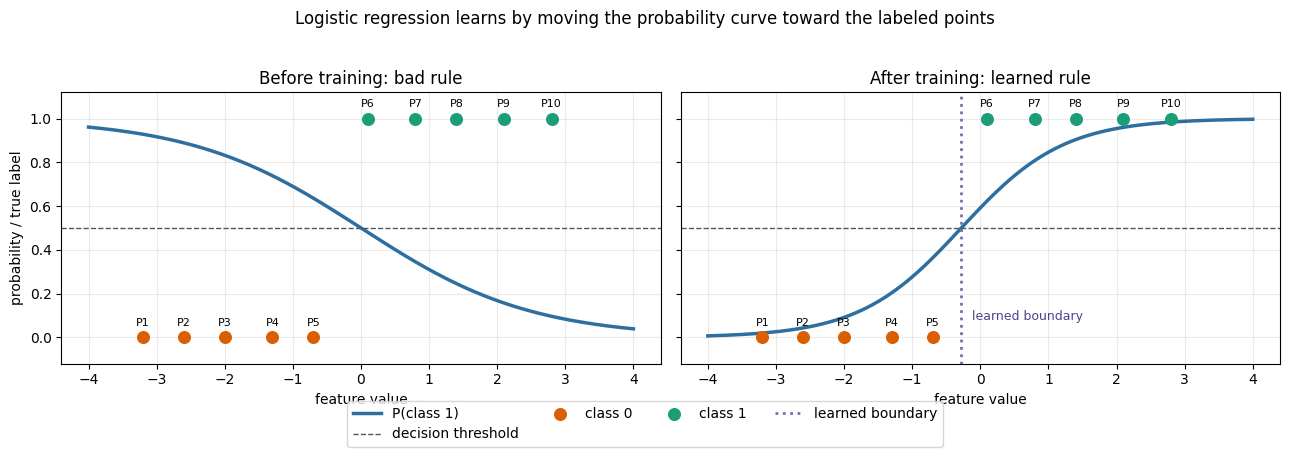

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# One feature, two classes. This keeps the curve easy to see.
x_demo = np.array([-3.2, -2.6, -2.0, -1.3, -0.7, 0.1, 0.8, 1.4, 2.1, 2.8]).reshape(-1, 1)
y_demo = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
point_labels = [f"P{i}" for i in range(1, len(y_demo) + 1)]

# A deliberately poor rule before learning: it slopes the wrong way.
before_weight = -0.8
before_bias = 0.0

# The learned rule after fitting logistic regression.
demo_model = LogisticRegression()
demo_model.fit(x_demo, y_demo)

x_grid = np.linspace(-4, 4, 400).reshape(-1, 1)
before_prob = sigmoid(before_weight * x_grid.ravel() + before_bias)
after_prob = demo_model.predict_proba(x_grid)[:, 1]
decision_x = -demo_model.intercept_[0] / demo_model.coef_[0][0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
plots = [
    (axes[0], before_prob, "Before training: bad rule"),
    (axes[1], after_prob, "After training: learned rule"),
]

for ax, probs, title in plots:
    ax.plot(x_grid.ravel(), probs, color="#2f6f9f", linewidth=2.5, label="P(class 1)")
    ax.axhline(0.5, color="#555555", linestyle="--", linewidth=1, label="decision threshold")
    ax.scatter(x_demo[y_demo == 0], y_demo[y_demo == 0], color="#d95f02", s=70, label="class 0", zorder=3)
    ax.scatter(x_demo[y_demo == 1], y_demo[y_demo == 1], color="#1b9e77", s=70, label="class 1", zorder=3)
    for label, x_value, y_value in zip(point_labels, x_demo.ravel(), y_demo):
        ax.annotate(label, (x_value, y_value), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("feature value")
    ax.set_ylim(-0.12, 1.12)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("probability / true label")
axes[1].axvline(decision_x, color="#7570b3", linestyle=":", linewidth=2, label="learned boundary")
axes[1].annotate("learned boundary", (decision_x, 0.08), textcoords="offset points", xytext=(8, 0), fontsize=9, color="#4d448f")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Logistic regression learns by moving the probability curve toward the labeled points", y=1.03)
plt.tight_layout()
plt.show()


## Visual intuition: what changes during learning

**This figure answers:** What happens between "bad initial rule" and "trained model"?

A logistic regression model has two important learned numbers in this one-feature example:

- `weight`: controls how steeply probability changes as the feature changes
- `bias`: shifts the curve left or right

How to read the left plot:

- Each colored curve is the model after a different number of training steps.
- Earlier curves are worse; later curves should line up better with class 0 on the left and class 1 on the right.
- The dots are still the true labels, so the curve should move toward those dots.

How to read the right plot:

- The x-axis is training step.
- The y-axis is loss, a number that measures probability mistakes.
- Lower loss means the predicted probabilities match the labels better.

What to observe:

- The probability curve gradually rotates and shifts toward the data.
- The loss curve drops as the model gets better.

Student takeaway: training is repeated parameter adjustment, not a one-shot guess.


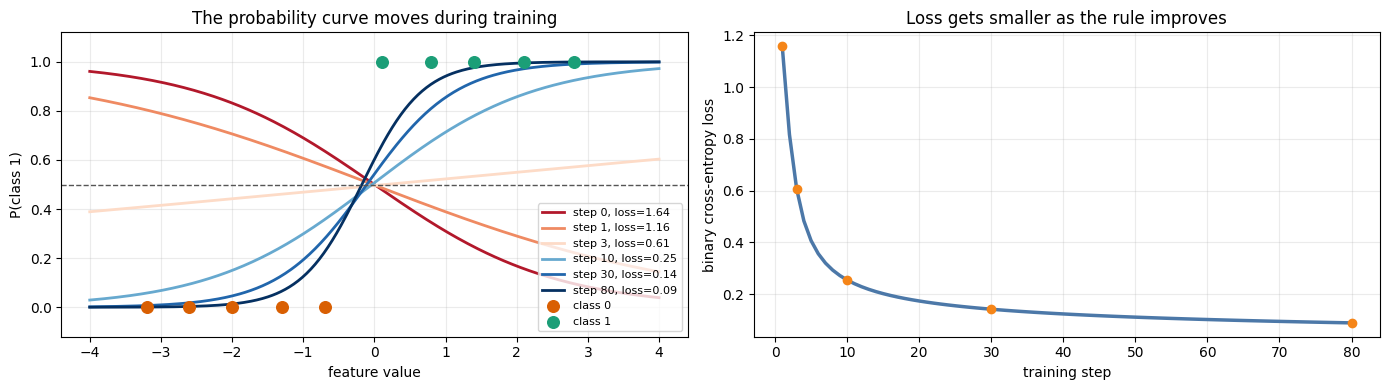

In [2]:
def binary_cross_entropy(y_true, y_prob):
    y_prob = np.clip(y_prob, 1e-8, 1 - 1e-8)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))


x_flat = x_demo.ravel()
weight = before_weight
bias = before_bias
learning_rate = 0.25
epochs = 80
snapshots = {0: (weight, bias, binary_cross_entropy(y_demo, sigmoid(weight * x_flat + bias)))}
loss_history = []

for epoch in range(1, epochs + 1):
    probs = sigmoid(weight * x_flat + bias)
    error = probs - y_demo
    grad_w = np.mean(error * x_flat)
    grad_b = np.mean(error)

    weight -= learning_rate * grad_w
    bias -= learning_rate * grad_b

    loss = binary_cross_entropy(y_demo, sigmoid(weight * x_flat + bias))
    loss_history.append(loss)
    if epoch in [1, 3, 10, 30, 80]:
        snapshots[epoch] = (weight, bias, loss)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["#b2182b", "#ef8a62", "#fddbc7", "#67a9cf", "#2166ac", "#053061"]

for (epoch, (w, b, loss)), color in zip(snapshots.items(), colors):
    probs = sigmoid(w * x_grid.ravel() + b)
    axes[0].plot(x_grid.ravel(), probs, color=color, linewidth=2, label=f"step {epoch}, loss={loss:.2f}")

axes[0].scatter(x_demo[y_demo == 0], y_demo[y_demo == 0], color="#d95f02", s=70, label="class 0", zorder=3)
axes[0].scatter(x_demo[y_demo == 1], y_demo[y_demo == 1], color="#1b9e77", s=70, label="class 1", zorder=3)
axes[0].axhline(0.5, color="#555555", linestyle="--", linewidth=1)
axes[0].set_title("The probability curve moves during training")
axes[0].set_xlabel("feature value")
axes[0].set_ylabel("P(class 1)")
axes[0].set_ylim(-0.12, 1.12)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, loc="lower right")

axes[1].plot(range(1, epochs + 1), loss_history, color="#4c78a8", linewidth=2.5)
axes[1].scatter([1, 3, 10, 30, 80], [snapshots[e][2] for e in [1, 3, 10, 30, 80]], color="#f58518", zorder=3)
axes[1].set_title("Loss gets smaller as the rule improves")
axes[1].set_xlabel("training step")
axes[1].set_ylabel("binary cross-entropy loss")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Visual intuition: predictions for each data point

**This figure answers:** What does the trained model predict for each individual example?

The model does not output only `class 0` or `class 1`. It first outputs a probability.

How to read it:

- The x-axis lists the training examples `P1`, `P2`, ...
- The y-axis is `P(class 1)`, the trained model's probability for class 1.
- The dashed line at `0.5` is the class decision threshold.
- Each bar label shows the true label, predicted label, and probability.

What to observe:

- Class 0 examples should have bars below `0.5`.
- Class 1 examples should have bars above `0.5`.
- Bars close to `0.5` are uncertain examples, even if the final class prediction is correct.

Student takeaway: classification is usually probability first, hard label second.


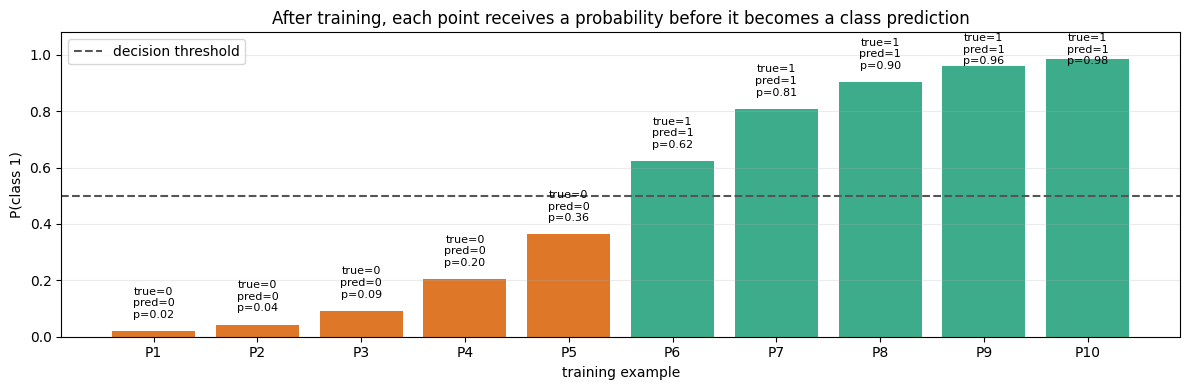

In [3]:
point_probs = demo_model.predict_proba(x_demo)[:, 1]
point_preds = (point_probs >= 0.5).astype(int)
bar_colors = np.where(y_demo == 1, "#1b9e77", "#d95f02")

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(point_labels, point_probs, color=bar_colors, alpha=0.85)
ax.axhline(0.5, color="#555555", linestyle="--", linewidth=1.5, label="decision threshold")

for bar, true_label, pred_label, prob in zip(bars, y_demo, point_preds, point_probs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(prob + 0.04, 0.96),
        f"true={true_label}\npred={pred_label}\np={prob:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_title("After training, each point receives a probability before it becomes a class prediction")
ax.set_xlabel("training example")
ax.set_ylabel("P(class 1)")
ax.set_ylim(0, 1.08)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### Reading the three visuals together

The three pictures tell one learning story:

1. **Before/after curve:** the model starts with a bad rule and ends with a better rule.
2. **Training steps + loss:** the rule improves through repeated updates, and loss falls as probability mistakes shrink.
3. **Per-point probabilities:** the final model gives every point a probability before turning it into a class label.

When students explain machine learning, they should be able to say:

- What data the model learned from.
- What changed during training.
- What metric or loss showed improvement.
- How the final model makes predictions.

The rest of the notebook applies the same idea to the Iris dataset and saves the experiment artifacts.


### What this cell does
Defines `TrainConfig` — a typed dataclass holding all hyperparameters — and `run_once()` which executes one full training loop iteration.

**Key design decisions:**
- **`TrainConfig` dataclass:** All parameters in one place. When you save `config.json`, you save the exact settings that produced the result. No guessing later.
- **`stratify=y` in `train_test_split`:** Ensures each class appears proportionally in both train and validation sets. Without this, a small dataset might have all examples of one class in train and none in validation.
- **`StandardScaler`:** Fit on train data only, then applied to validation. Fitting on the full dataset would "leak" validation statistics into training — a subtle but common mistake.
- **Artifacts saved per run:** `result.json` (single run) and `training_loop_summary.json` (all candidates ranked). This is your audit trail.

**What to check:** After running, open `output/run_.../result.json` and verify the metrics match what's printed.

In [4]:
from dataclasses import dataclass
from pathlib import Path
import json
import joblib
from datetime import datetime
import time

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler


OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


@dataclass
class TrainConfig:
    seed: int = 7
    test_size: float = 0.25
    max_iter: int = 250


cfg = TrainConfig()
print(cfg)

TrainConfig(seed=7, test_size=0.25, max_iter=250)


### Task 1.1: Load Data

Load a dataset and inspect basic shapes/labels. We'll use Iris for a small reproducible example.

In [5]:
# Load Iris dataset
data = load_iris(as_frame=True)
X = data.data
y = data.target

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print("\nFirst 3 rows of features:")
print(X.head(3))
print("\nClass distribution:")
print(y.value_counts())

Features shape: (150, 4)
Labels shape: (150,)

First 3 rows of features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2

Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


### Task 1.2: Train/Validation Split & Preprocessing

We need to hold out some data to honestly evaluate the model. We also scale the features. 
**Crucial**: Fit the scaler only on the training data, then transform the validation data to prevent data leakage.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=cfg.test_size, random_state=cfg.seed, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

print("\nFeature means after scaling (Train):", X_train_s.mean(axis=0))
print("Feature means after scaling (Val):", X_val_s.mean(axis=0))

Training set size: 112
Validation set size: 38

Feature means after scaling (Train): [ 5.70971841e-16  1.01506105e-15 -1.26882631e-16  2.29974769e-16]
Feature means after scaling (Val): [-0.16690571 -0.10741899 -0.07138625 -0.07201851]


### Task 1.3: Train the Model

We initialize and train a `LogisticRegression` baseline model using parameters from `TrainConfig`.

In [7]:
model = LogisticRegression(max_iter=cfg.max_iter, random_state=cfg.seed)

start_time = time.time()
model.fit(X_train_s, y_train)
train_time = time.time() - start_time

print(f"Model trained in {train_time:.4f} seconds")
print(f"Model classes: {model.classes_}")

Model trained in 0.0045 seconds
Model classes: [0 1 2]


### Task 1.4: Evaluate the Model

We compute metrics on the validation set, including a full classification report.

In [8]:
pred = model.predict(X_val_s)

acc = float(accuracy_score(y_val, pred))
f1 = float(f1_score(y_val, pred, average="macro"))
report = classification_report(y_val, pred)

metrics = {
    "accuracy": acc,
    "f1_macro": f1,
    "train_time_seconds": train_time
}

print(f"Accuracy: {acc:.4f}")
print(f"F1 (macro): {f1:.4f}")
print("\nClassification Report:\n")
print(report)

Accuracy: 0.9737
F1 (macro): 0.9733

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.92      0.96        13
           2       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



### Task 1.5: Save Artifacts

This is the core of ML discipline. Every run produces a traceable folder containing the configuration, metrics, reports, and the model itself.

In [9]:
# Create a unique run ID using the current timestamp
run_id = datetime.utcnow().strftime("run_%Y%m%d_%H%M%S")
run_dir = OUTPUT_DIR / run_id
run_dir.mkdir(exist_ok=True)

# 1. Save config
config_dict = {"seed": cfg.seed, "test_size": cfg.test_size, "max_iter": cfg.max_iter}
(run_dir / "config.json").write_text(json.dumps(config_dict, indent=2), encoding="utf-8")

# 2. Save metrics
(run_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

# 3. Save validation report
(run_dir / "val_report.txt").write_text(report, encoding="utf-8")

# 4. Save model
joblib.dump(model, run_dir / "model.joblib")

print(f"Saved artifacts to {run_dir}:")
for f in run_dir.iterdir():
    print(f" - {f.name}")

Saved artifacts to output/run_20260606_004452:
 - metrics.json
 - model.joblib
 - val_report.txt
 - config.json


### Task 1.6: The Full Loop (Putting it together)

Let's wrap these steps into a function, run multiple configurations, and save a summary. This proves we can automate experimentation and compare runs.

In [10]:
def run_once(seed: int, test_size: float, max_iter: int) -> dict:
    """Executes a full training loop and saves artifacts."""
    # Split
    X_tr, X_v, y_tr, y_v = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )
    
    # Scale
    scl = StandardScaler()
    X_tr_s = scl.fit_transform(X_tr)
    X_v_s = scl.transform(X_v)
    
    # Train
    t0 = time.time()
    clf = LogisticRegression(max_iter=max_iter, random_state=seed)
    clf.fit(X_tr_s, y_tr)
    t_diff = time.time() - t0
    
    # Evaluate
    p = clf.predict(X_v_s)
    m = {
        "accuracy": float(accuracy_score(y_v, p)),
        "f1_macro": float(f1_score(y_v, p, average="macro")),
        "train_time_seconds": t_diff
    }
    rep = classification_report(y_v, p)
    
    # Save Artifacts
    rid = datetime.utcnow().strftime("run_%Y%m%d_%H%M%S_%f") # add microsecond to avoid rapid run clashes
    rdir = OUTPUT_DIR / rid
    rdir.mkdir(exist_ok=True)
    
    cfg_dict = {"seed": seed, "test_size": test_size, "max_iter": max_iter}
    (rdir / "config.json").write_text(json.dumps(cfg_dict, indent=2), encoding="utf-8")
    (rdir / "metrics.json").write_text(json.dumps(m, indent=2), encoding="utf-8")
    (rdir / "val_report.txt").write_text(rep, encoding="utf-8")
    joblib.dump(clf, rdir / "model.joblib")
    
    return {
        "run_id": rid,
        "config": cfg_dict,
        "metrics": m
    }

# Run multiple candidates
candidates = [
    {"seed": 7, "test_size": 0.25, "max_iter": 100},
    {"seed": 7, "test_size": 0.25, "max_iter": 400},
    {"seed": 13, "test_size": 0.20, "max_iter": 250},
]

print("Running candidates...")
results = [run_once(**c) for c in candidates]
results_sorted = sorted(results, key=lambda r: r["metrics"]["accuracy"], reverse=True)

summary = {
    "best": results_sorted[0],
    "all": results_sorted,
}

summary_path = OUTPUT_DIR / "training_loop_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"\nWrote summary to: {summary_path}")
print("Best config:", summary["best"]["config"])
print("Best metrics:", summary["best"]["metrics"])

Running candidates...

Wrote summary to: output/training_loop_summary.json
Best config: {'seed': 13, 'test_size': 0.2, 'max_iter': 250}
Best metrics: {'accuracy': 1.0, 'f1_macro': 1.0, 'train_time_seconds': 0.003136157989501953}
